# Model 1: County Clustering (KMeans Tiering)

## Overview
This notebook performs county-level clustering to identify tiers of HIV care gaps across Kenya's 47 counties.

**Methodology:**
- Uses KMeans clustering on CGI scores
- Produces 4 tiers: Critical, High, Moderate, Low
- Output saved to `data/processed/county_profiles.csv`

In [3]:
# Cell 1: Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

ROOT_PATH = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT_PATH not in sys.path:
    sys.path.append(ROOT_PATH)
import constants as c

print("Setup complete")
print(f"Constants loaded from: {c.__file__}")

Setup complete
Constants loaded from: /home/skylar_lorena/DS/Phase5/Phase-5-HIV-Care-Gap-AI/constants.py


In [4]:
# Cell 2: Load generated county profiles
df = pd.read_csv(c.COUNTY_PROF)

print(f"Loaded {len(df)} counties")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 5 rows:")
df.head()

Loaded 47 counties
Columns: ['county', 'tier', 'cgi_score', 'iit_rate_pct', 'adults_on_art']

First 5 rows:


,county,tier,cgi_score,iit_rate_pct,adults_on_art
0,Mandera,Critical,-110876.057932,0.112052,830
1,Wajir,Critical,-55416.057932,0.112052,405
2,Makueni,Critical,36.406126,0.088800,25027
3,Machakos,Critical,36.412102,0.088800,31351
4,Busia,Critical,36.473861,0.089500,37116


TIER DISTRIBUTION
Critical: 21 counties (44.7%)
High: 12 counties (25.5%)
Moderate: 14 counties (29.8%)
Low: 0 counties (0%)


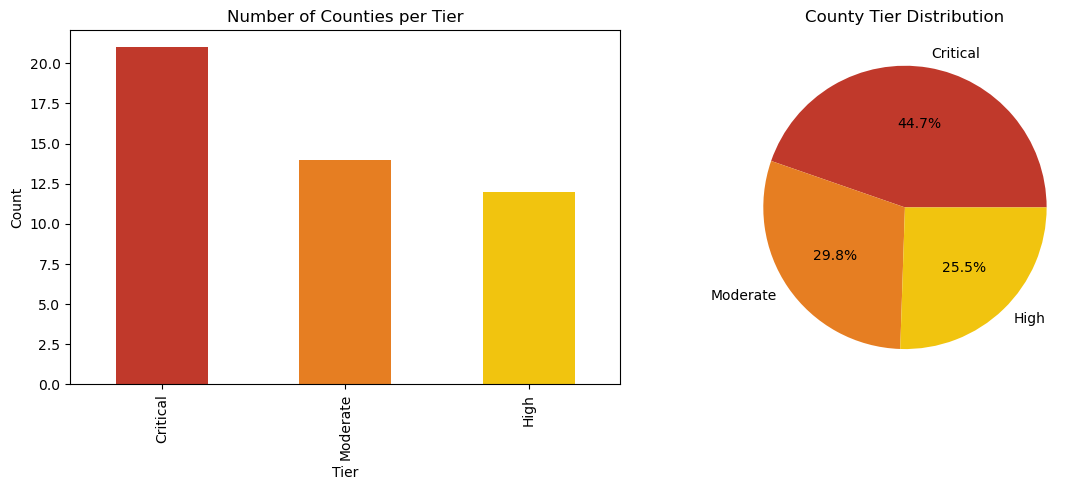

In [5]:
# Cell 3: Tier distribution
print("=" * 50)
print("TIER DISTRIBUTION")
print("=" * 50)

tier_counts = df["tier"].value_counts()
tier_percentages = (tier_counts / len(df) * 100).round(1)

for tier in ["Critical", "High", "Moderate", "Low"]:
    count = tier_counts.get(tier, 0)
    pct = tier_percentages.get(tier, 0)
    print(f"{tier}: {count} counties ({pct}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60"]
tier_counts.plot(kind="bar", ax=axes[0], color=colors)
axes[0].set_title("Number of Counties per Tier")
axes[0].set_xlabel("Tier")
axes[0].set_ylabel("Count")

# Pie chart
axes[1].pie(tier_counts, labels=tier_counts.index, colors=colors, autopct="%1.1f%%")
axes[1].set_title("County Tier Distribution")

plt.tight_layout()
plt.savefig("../figures/tier_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

CGI SCORE BY TIER
               min    mean   max  count
tier                                   
Critical -110876.1 -7884.9  38.8     21
High          40.0    41.8  46.8     12
Moderate      61.4    62.3  63.5     14


/tmp/ipykernel_378927/574328929.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


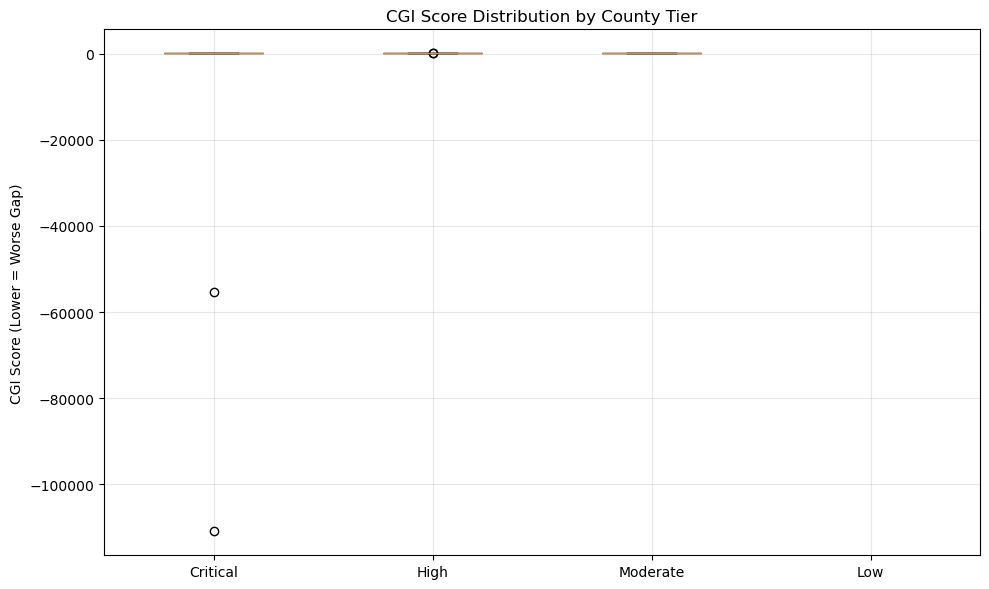

In [6]:
# Cell 4: CGI score distribution
print("=" * 50)
print("CGI SCORE BY TIER")
print("=" * 50)

tier_stats = (
    df.groupby("tier")["cgi_score"].agg(["min", "mean", "max", "count"]).round(1)
)
print(tier_stats)

# Box plot
plt.figure(figsize=(10, 6))
order = ["Critical", "High", "Moderate", "Low"]
colors = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60"]

bp = plt.boxplot(
    [df[df["tier"] == t]["cgi_score"] for t in order], labels=order, patch_artist=True
)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

plt.ylabel("CGI Score (Lower = Worse Gap)")
plt.title("CGI Score Distribution by County Tier")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/cgi_by_tier.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
# Cell 5: Counties with largest care gaps
critical_df = df[df["tier"] == "Critical"].sort_values("cgi_score", ascending=True)

print("=" * 50)
print("CRITICAL TIER COUNTIES (Highest Priority)")
print("=" * 50)

for i, row in critical_df.iterrows():
    print(f"  • {row['county']}: CGI = {row['cgi_score']:.1f}")

CRITICAL TIER COUNTIES (Highest Priority)
  • Mandera: CGI = -110876.1
  • Wajir: CGI = -55416.1
  • Makueni: CGI = 36.4
  • Machakos: CGI = 36.4
  • Busia: CGI = 36.5
  • Bungoma: CGI = 36.6
  • Kakamega: CGI = 36.7
  • Kitui: CGI = 36.7
  • Kisii: CGI = 36.9
  • Meru: CGI = 36.9
  • Tharaka Nithi: CGI = 37.0
  • Embu: CGI = 37.1
  • Vihiga: CGI = 37.1
  • Nyamira: CGI = 37.3
  • Kisumu: CGI = 37.4
  • Homa Bay: CGI = 37.5
  • Migori: CGI = 37.6
  • Marsabit: CGI = 38.4
  • Mombasa: CGI = 38.6
  • Kwale: CGI = 38.7
  • Isiolo: CGI = 38.8


In [8]:
# Cell 6: Save summary
summary = {
    "total_counties": len(df),
    "tier_counts": tier_counts.to_dict(),
    "cgi_range": {
        "min": df["cgi_score"].min(),
        "max": df["cgi_score"].max(),
        "mean": df["cgi_score"].mean(),
    },
}

import json

with open("../data/processed/county_tiering_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Summary saved to data/processed/county_tiering_summary.json")
print(json.dumps(summary, indent=2))

Summary saved to data/processed/county_tiering_summary.json
{
  "total_counties": 47,
  "tier_counts": {
    "Critical": 21,
    "Moderate": 14,
    "High": 12
  },
  "cgi_range": {
    "min": -110876.05793226382,
    "max": 63.47560975609756,
    "mean": -3493.819586473738
  }
}


In [11]:
# Cell 7: Check if dashboard can load this file
import os

if os.path.exists(c.COUNTY_PROF):
    print(f" COUNTY_PROF exists at: {c.COUNTY_PROF}")
    print(f"   Size: {os.path.getsize(c.COUNTY_PROF):,} bytes")
    print(f"   Rows: {len(df)}")
    print(f"   Columns: {len(df.columns)}")
    print("\n Dashboard Tab 1 ready to use!")
else:
    print(f" File not found at: {c.COUNTY_PROF}")
    

 COUNTY_PROF exists at: /home/skylar_lorena/DS/Phase5/Phase-5-HIV-Care-Gap-AI/data/processed/county_profiles.csv
   Size: 2,282 bytes
   Rows: 47
   Columns: 5

 Dashboard Tab 1 ready to use!
